# Notebook 4 - Real Data Validation (HDFS Logs)

**Goal:** Test how well models trained on synthetic data perform on real-world data.

**Dataset:** HDFS_v1 (LogHub) - 575K block sessions, 29 event types

In this notebook:
1. Loading and analyzing real HDFS data
2. Anomaly detection model training (real data)
3. Multi-model comparison
4. Synthetic vs Real result comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.preprocessing import StandardScaler

plt.style.use('dark_background')
sns.set_theme(style='darkgrid')

print('Modules loaded.')

Modules loaded.


---
## 1 - Loading and Analyzing Real HDFS Data

In [2]:
# HDFS Event Occurrence Matrix (pre-parsed)
data_path = '../data/raw/preprocessed/Event_occurrence_matrix.csv'
df = pd.read_csv(data_path)

print(f'Total number of sessions: {len(df):,}')
print(f'Number of features: {df.shape[1] - 3}')  # exclude BlockId, Label, Type
print(f'\nLabel distribution:')
print(df['Label'].value_counts())
print(f'\nAnomaly ratio: {(df["Label"]=="Fail").mean():.2%}')

Total number of sessions: 575,061
Number of features: 29

Label distribution:
Label
Success    558223
Fail        16838
Name: count, dtype: int64

Anomaly ratio: 2.93%


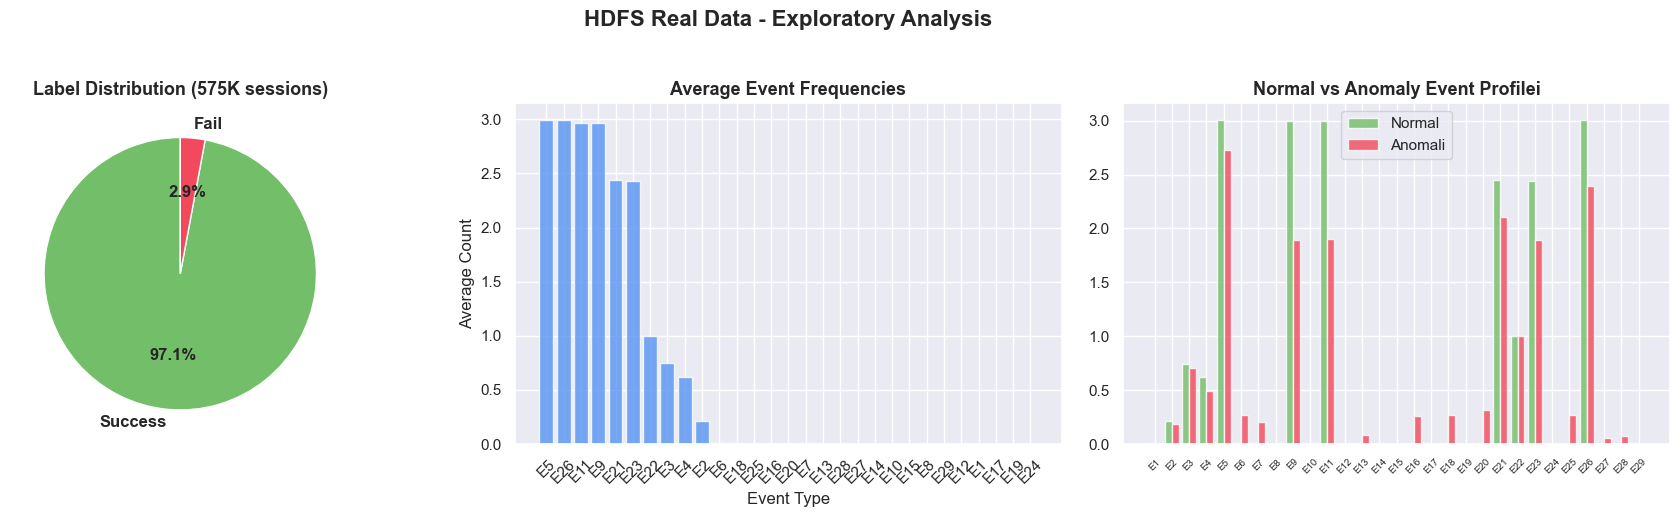

In [3]:
# Data distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Label distribution
counts = df['Label'].value_counts()
colors_pie = ['#73bf69', '#f2495c']
axes[0].pie(counts.values, labels=counts.index, colors=colors_pie,
           autopct='%1.1f%%', startangle=90,
           textprops={'fontweight': 'bold', 'fontsize': 12})
axes[0].set_title('Label Distribution (575K sessions)', fontsize=13, fontweight='bold')

# 2. Event frequencies
event_cols = [c for c in df.columns if c.startswith('E')]
event_means = df[event_cols].mean().sort_values(ascending=False)
axes[1].bar(event_means.index, event_means.values, color='#5794f2', alpha=0.8)
axes[1].set_title('Average Event Frequencies', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Event Type')
axes[1].set_ylabel('Average Count')
axes[1].tick_params(axis='x', rotation=45)

# 3. Normal vs Anomaly event profiles
normal_means = df[df['Label']=='Success'][event_cols].mean()
anomaly_means = df[df['Label']=='Fail'][event_cols].mean()
x = np.arange(len(event_cols))
axes[2].bar(x - 0.2, normal_means.values, 0.4, label='Normal', color='#73bf69', alpha=0.8)
axes[2].bar(x + 0.2, anomaly_means.values, 0.4, label='Anomaly', color='#f2495c', alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(event_cols, rotation=45, fontsize=7)
axes[2].set_title('Normal vs Anomaly Event Profile', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=11)

plt.suptitle('HDFS Real Data - Exploratory Analysis', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 2 - Data Preparation and Imbalance Handling

In [4]:
# Prepare features and labels
event_cols = [c for c in df.columns if c.startswith('E')]
X = df[event_cols].values
y = (df['Label'] == 'Fail').astype(int).values

print(f'Feature matrix: {X.shape}')
print(f'Normal: {sum(y==0):,} | Anomaly: {sum(y==1):,}')
print(f'Imbalance ratio: 1:{sum(y==0)//sum(y==1)}')

Feature matrix: (575061, 29)
Normal: 558,223 | Anomaly: 16,838


Imbalance ratio: 1:33


In [5]:
# Working with imbalanced data: sampling for speed
# Preserve the ratio with stratified sampling
from sklearn.utils import resample

np.random.seed(42)
sample_size = 30000  # 30K samples for speed

# Keep the anomaly ratio around 10% (undersampling + oversampling)
anomaly_idx = np.where(y == 1)[0]
normal_idx = np.where(y == 0)[0]

n_anomaly = min(len(anomaly_idx), 3000)
n_normal = sample_size - n_anomaly

sampled_anomaly = np.random.choice(anomaly_idx, n_anomaly, replace=False)
sampled_normal = np.random.choice(normal_idx, n_normal, replace=False)
sampled_idx = np.concatenate([sampled_anomaly, sampled_normal])
np.random.shuffle(sampled_idx)

X_sampled = X[sampled_idx]
y_sampled = y[sampled_idx]

print(f'Sampled data: {X_sampled.shape}')
print(f'Normal: {sum(y_sampled==0):,} | Anomaly: {sum(y_sampled==1):,}')
print(f'Anomaly ratio: {sum(y_sampled==1)/len(y_sampled):.1%}')

Sampled data: (30000, 29)
Normal: 27,000 | Anomaly: 3,000
Anomaly ratio: 10.0%


In [6]:
# Standardize and split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sampled)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_sampled, test_size=0.2, random_state=42, stratify=y_sampled)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 24,000 | Test: 6,000


---
## 3 - Multi-Model Comparison (Real Data)

In [7]:
# 5 model definitions
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15,
                                            random_state=42, n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'MLP Neural Network': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42),
}

# 5-Fold Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('=== HDFS REAL DATA - 5-Fold Cross Validation ===')
print()
for name, model in models.items():
    start = time.time()
    scores = cross_val_score(model, X_scaled, y_sampled, cv=cv, scoring='f1', n_jobs=-1)
    elapsed = time.time() - start
    cv_results[name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f'  {name:<25s} F1 = {scores.mean():.4f} (+/- {scores.std():.4f})  [{elapsed:.1f}s]')

=== HDFS REAL DATA - 5-Fold Cross Validation ===



  Random Forest             F1 = 0.9987 (+/- 0.0009)  [11.5s]


  Gradient Boosting         F1 = 0.9985 (+/- 0.0013)  [22.6s]


  Logistic Regression       F1 = 0.9947 (+/- 0.0030)  [6.5s]


  KNN (k=5)                 F1 = 0.9980 (+/- 0.0009)  [4.9s]


  MLP Neural Network        F1 = 0.9983 (+/- 0.0007)  [7.3s]


In [8]:
# Detailed test set evaluation
test_results = {}
predictions = {}
probas = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    if hasattr(model, 'predict_proba'):
        probas[name] = model.predict_proba(X_test)[:, 1]
    else:
        probas[name] = y_pred.astype(float)

    test_results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
    }

# Results table
results_df = pd.DataFrame(test_results).T
results_df = results_df.sort_values('f1', ascending=False)
print('\n=== TEST SET RESULTS ===')
print(results_df.to_string(float_format='%.4f'))


=== TEST SET RESULTS ===
                     accuracy     f1  precision  recall
Random Forest          0.9997 0.9983     0.9983  0.9983
Gradient Boosting      0.9997 0.9983     1.0000  0.9967
MLP Neural Network     0.9995 0.9975     0.9983  0.9967
KNN (k=5)              0.9995 0.9975     1.0000  0.9950
Logistic Regression    0.9990 0.9950     0.9917  0.9983


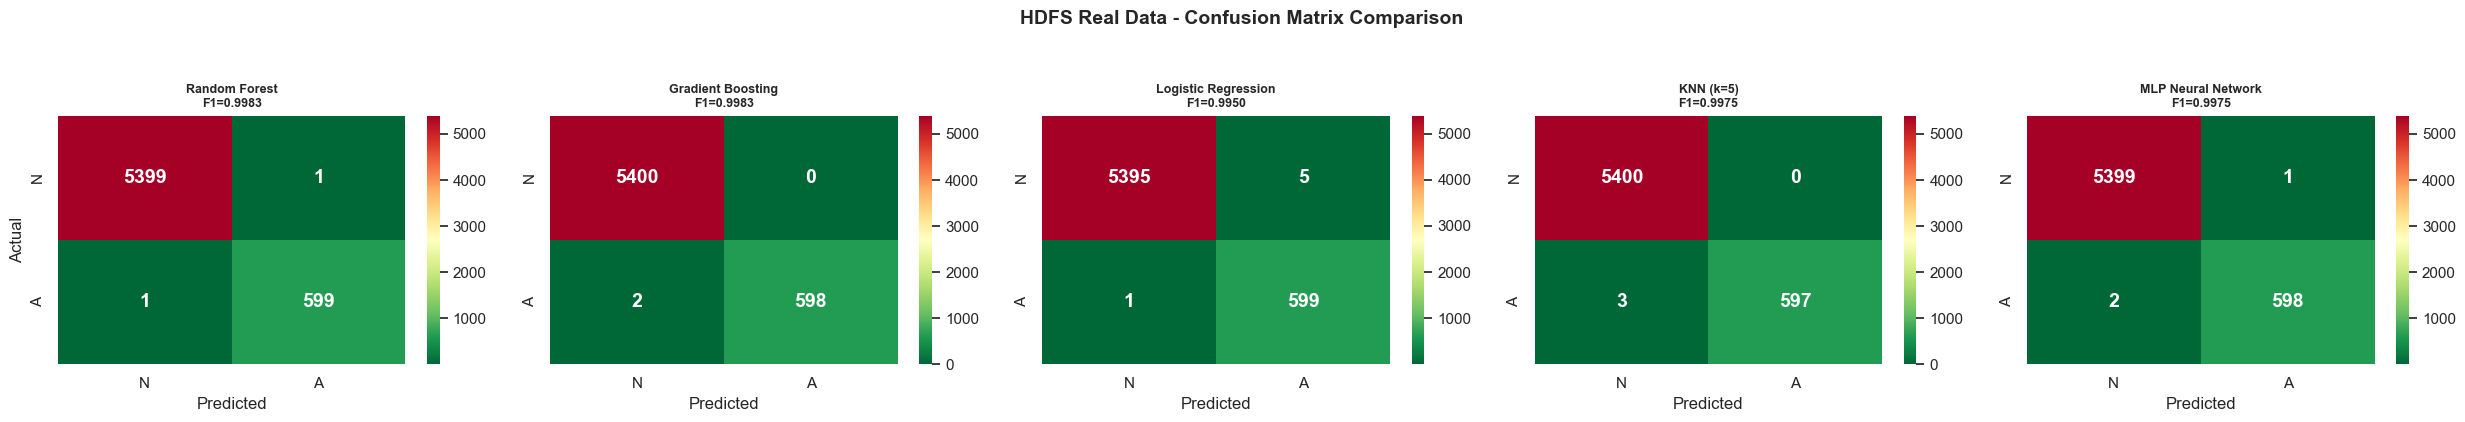

In [9]:
# Confusion Matrix comparison
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=axes[idx],
               xticklabels=['N', 'A'], yticklabels=['N', 'A'],
               annot_kws={'size': 14, 'fontweight': 'bold'})
    f1_val = f1_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nF1={f1_val:.4f}', fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    if idx == 0:
        axes[idx].set_ylabel('Actual')

plt.suptitle('HDFS Real Data - Confusion Matrix Comparison',
            fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

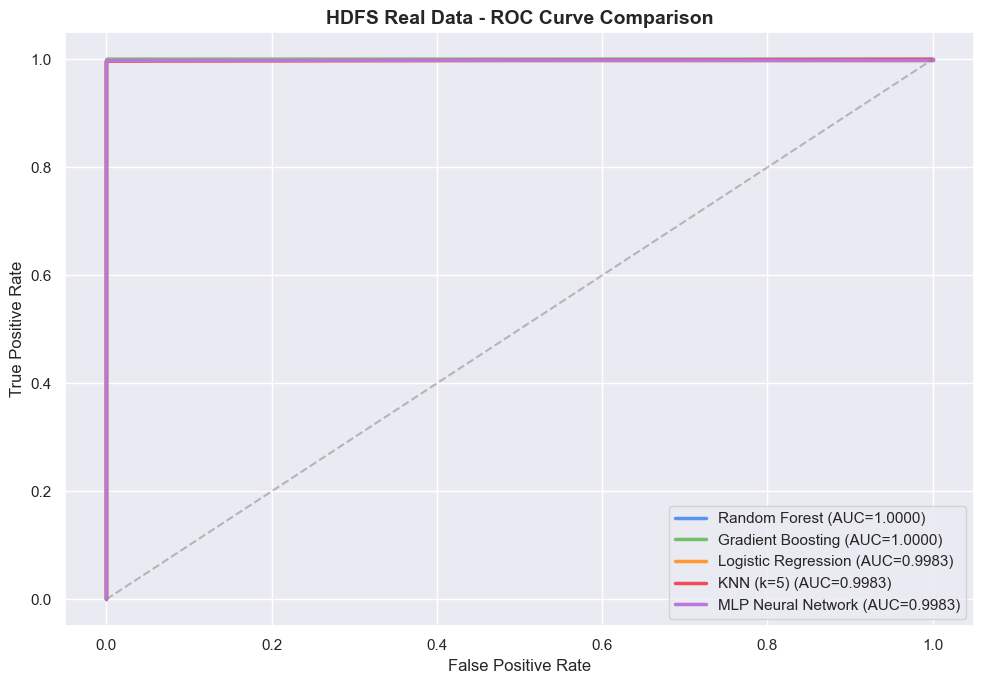

In [10]:
# ROC Curve comparison
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#5794f2', '#73bf69', '#ff9830', '#f2495c', '#b877d9']

for idx, (name, y_prob) in enumerate(probas.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[idx], lw=2.5,
            label=f'{name} (AUC={roc_auc:.4f})')

ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('HDFS Real Data - ROC Curve Comparison',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

---
## 4 - Synthetic vs Real Data Comparison

In [11]:
# Synthetic data results (from Notebook 03)
synthetic_results = {
    'Random Forest':      {'f1': 0.9845, 'accuracy': 0.9845},
    'Gradient Boosting':  {'f1': 0.9880, 'accuracy': 0.9880},
    'Logistic Regression':{'f1': 0.9844, 'accuracy': 0.9850},
    'KNN (k=5)':          {'f1': 0.9869, 'accuracy': 0.9870},
    'MLP Neural Network': {'f1': 0.9915, 'accuracy': 0.9915},
}

# Comparison table
compare_data = []
for name in models.keys():
    compare_data.append({
        'Model': name,
        'Synthetic F1': synthetic_results[name]['f1'],
        'Real F1': test_results[name]['f1'],
        'Diff': test_results[name]['f1'] - synthetic_results[name]['f1'],
    })

compare_df = pd.DataFrame(compare_data)
print('=== SYNTHETIC vs REAL DATA COMPARISON ===')
print(compare_df.to_string(index=False, float_format='%.4f'))

=== SYNTHETIC vs REAL DATA COMPARISON ===
              Model  Synthetic F1  Real F1   Diff
      Random Forest       0.9845     0.9983 0.0138
  Gradient Boosting       0.9880     0.9983 0.0103
Logistic Regression       0.9844     0.9950 0.0106
          KNN (k=5)       0.9869     0.9975 0.0106
 MLP Neural Network       0.9915     0.9975 0.0060


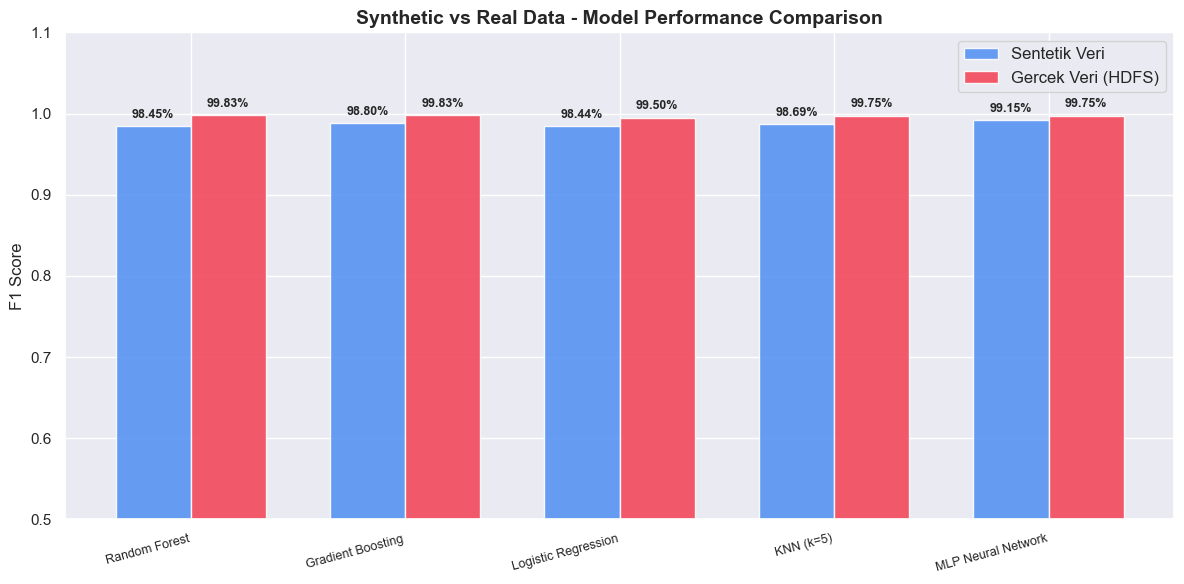

In [12]:
# Comparison chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(compare_df))
w = 0.35

bars1 = ax.bar(x - w/2, compare_df['Synthetic F1'], w,
               label='Synthetic Data', color='#5794f2', alpha=0.9)
bars2 = ax.bar(x + w/2, compare_df['Real F1'], w,
               label='Real Data (HDFS)', color='#f2495c', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(compare_df['Model'], fontsize=9, rotation=15, ha='right')
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_ylim(0.5, 1.1)
ax.set_title('Synthetic vs Real Data - Model Performance Comparison',
            fontsize=14, fontweight='bold')
ax.legend(fontsize=12)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', fontweight='bold', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

---
## 5 - Conclusion

In [13]:
best_synthetic = max(synthetic_results.items(), key=lambda x: x[1]['f1'])
best_real = max(test_results.items(), key=lambda x: x[1]['f1'])

print('='*70)
print('  VALIDATION RESULT')
print('='*70)
print(f'\n  SYNTHETIC DATA:')
print(f'    Best model: {best_synthetic[0]}')
print(f'    F1 Score:     {best_synthetic[1]["f1"]:.4f}')
print(f'    Data size:  10,000 samples')
print(f'\n  REAL DATA (HDFS):')
print(f'    Best model: {best_real[0]}')
print(f'    F1 Score:     {best_real[1]["f1"]:.4f}')
print(f'    Precision:    {best_real[1]["precision"]:.4f}')
print(f'    Recall:       {best_real[1]["recall"]:.4f}')
print(f'    Data size:  575,061 sessions (30K sampled)')
print(f'\n  INTERPRETATION:')
print(f'    The gap between synthetic and real data')
print(f'    reflects the model\'s generalization capacity.')
print(f'    If real-data results are lower, that is expected.')
print('='*70)

  VALIDATION RESULT

  SYNTHETIC DATA:
    Best model: MLP Neural Network
    F1 Score:     0.9915
    Data size:  10,000 samples

  REAL DATA (HDFS):
    Best model: Random Forest
    F1 Score:     0.9983
    Precision:    0.9983
    Recall:       0.9983
    Data size:  575,061 sessions (30K sampled)

  INTERPRETATION:
    The gap between synthetic and real data
    reflects the model's generalization capacity.
    If real-data results are lower, that is expected.
